In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def show(title, img, cmap='gray'):
    plt.figure(figsize=(6, 4))
    plt.title(title)
    plt.axis('off')
    plt.imshow(img, cmap=cmap)
    plt.tight_layout()
    plt.show()

def show_multi(titles, images, cmaps=None, cols=3):
    """Display a row of images side by side – useful for comparisons"""
    n = len(images)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).flatten()
    for i, (ax, title, img) in enumerate(zip(axes, titles, images)):
        cmap = (cmaps[i] if cmaps else 'gray')
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    for ax in axes[n:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

print('OpenCV version:', cv2.__version__)
print('NumPy version: ', np.__version__)

OpenCV version: 4.13.0
NumPy version:  2.0.2


---
## 1. Creating / Reading Images  –  `cv2.imread` and `np` arrays

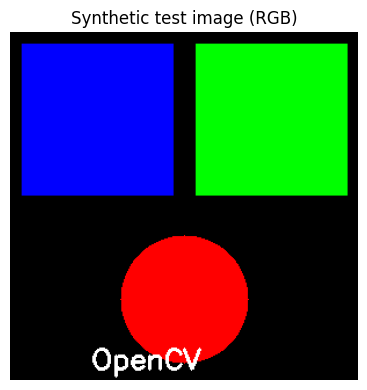

Image shape (H, W, Channels): (300, 300, 3)
Data type: uint8


In [2]:
test_img = np.zeros((300, 300, 3), dtype=np.uint8)

cv2.rectangle(test_img, (10, 10), (140, 140), (255, 0, 0), -1)

cv2.rectangle(test_img, (160, 10), (290, 140), (0, 255, 0), -1)

cv2.circle(test_img, (150, 230), 55, (0, 0, 255), -1)

cv2.putText(test_img, 'OpenCV', (70, 290),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
show('Synthetic test image (RGB)', img_rgb, cmap=None)

print('Image shape (H, W, Channels):', test_img.shape)
print('Data type:', test_img.dtype)

---
## 2. Colour Space Conversions  –  `cv2.cvtColor`

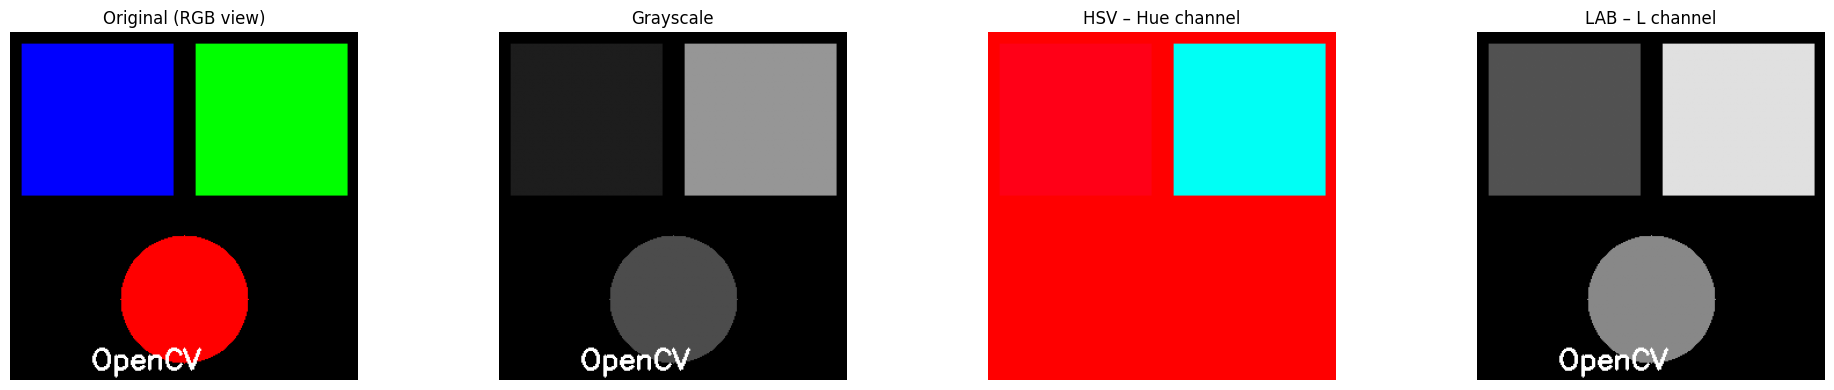

Gray pixel at (150,150): 0
HSV  pixel at (150,150): [0 0 0]


In [3]:

gray = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)

hsv = cv2.cvtColor(test_img, cv2.COLOR_BGR2HSV)

rgb  = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

lab = cv2.cvtColor(test_img, cv2.COLOR_BGR2LAB)

show_multi(
    ['Original (RGB view)', 'Grayscale', 'HSV – Hue channel', 'LAB – L channel'],
    [rgb, gray, hsv[:, :, 0], lab[:, :, 0]],
    cmaps=[None, 'gray', 'hsv', 'gray'],
    cols=4
)

print('Gray pixel at (150,150):', gray[150, 150])
print('HSV  pixel at (150,150):', hsv[150, 150])

---
## 3. Image Resizing and Scaling  –  `cv2.resize`

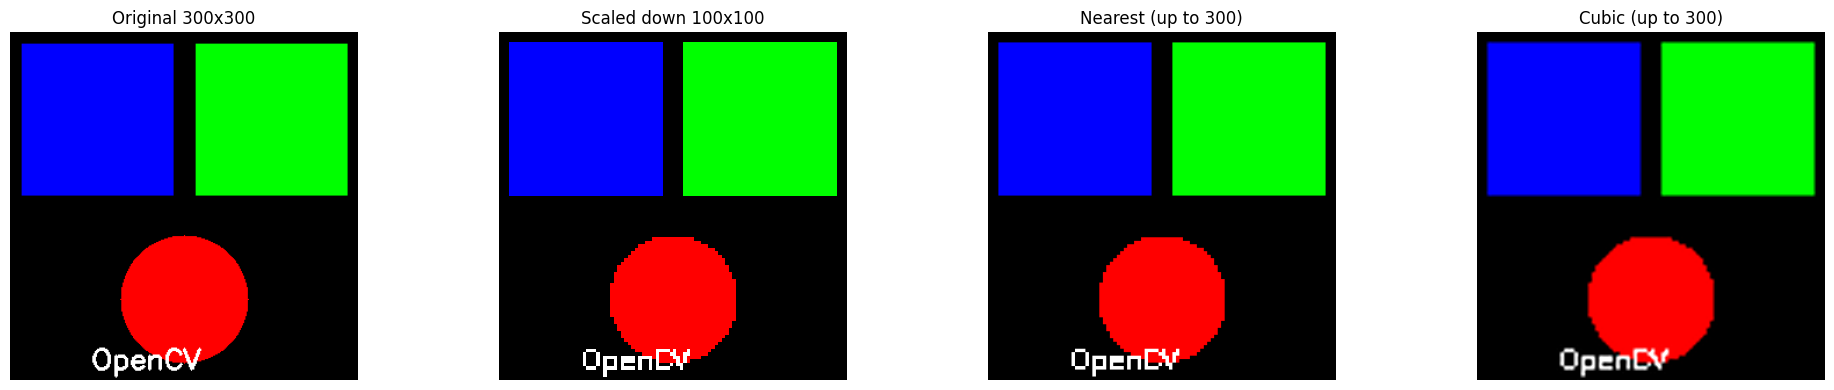

Original shape: (300, 300, 3)
Small shape:    (100, 100, 3)
Half shape:     (150, 150, 3)


In [5]:
small = cv2.resize(test_img, (100, 100))

half  = cv2.resize(test_img, None, fx=0.5, fy=0.5)

nearest = cv2.resize(small, (300, 300), interpolation=cv2.INTER_NEAREST)
cubic   = cv2.resize(small, (300, 300), interpolation=cv2.INTER_CUBIC)

show_multi(
    ['Original 300x300', 'Scaled down 100x100',
     'Nearest (up to 300)', 'Cubic (up to 300)'],
    [cv2.cvtColor(x, cv2.COLOR_BGR2RGB) for x in [test_img, small, nearest, cubic]],
    cmaps=[None]*4,
    cols=4
)

print('Original shape:', test_img.shape)
print('Small shape:   ', small.shape)
print('Half shape:    ', half.shape)

---
## 4. Drawing Functions  –  `rectangle`, `circle`, `line`, `putText`

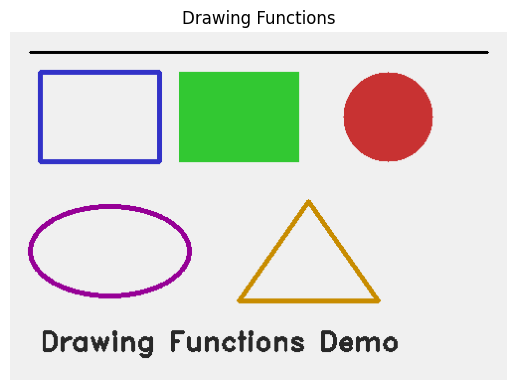

In [6]:
# Start with a clean white canvas
canvas = np.ones((350, 500, 3), dtype=np.uint8) * 240  # light grey

# cv2.line(image, start_pt, end_pt, colour_BGR, thickness)
cv2.line(canvas, (20, 20), (480, 20), (0, 0, 0), 2)

# cv2.rectangle(image, top_left, bottom_right, colour, thickness)
# thickness=-1 means filled
cv2.rectangle(canvas, (30, 40), (150, 130), (200, 50, 50), 3)
cv2.rectangle(canvas, (170, 40), (290, 130), (50, 200, 50), -1)  # filled

# cv2.circle(image, centre, radius, colour, thickness)
cv2.circle(canvas, (380, 85), 45, (50, 50, 200), -1)

# cv2.ellipse(image, centre, axes, angle, startAngle, endAngle, colour, thickness)
cv2.ellipse(canvas, (100, 220), (80, 45), 0, 0, 360, (150, 0, 150), 3)

# cv2.polylines – draw a polygon
pts = np.array([[300, 170], [370, 270], [230, 270]], dtype=np.int32)
cv2.polylines(canvas, [pts], isClosed=True, color=(0, 140, 200), thickness=3)

# cv2.putText(image, text, origin, font, scale, colour, thickness)
cv2.putText(canvas, 'Drawing Functions Demo', (30, 320),
            cv2.FONT_HERSHEY_DUPLEX, 0.9, (40, 40, 40), 2)

show('Drawing Functions', cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB), cmap=None)

---
## 5. Image Thresholding  –  `cv2.threshold` and `cv2.adaptiveThreshold`

Otsu automatically chose threshold = 29.0


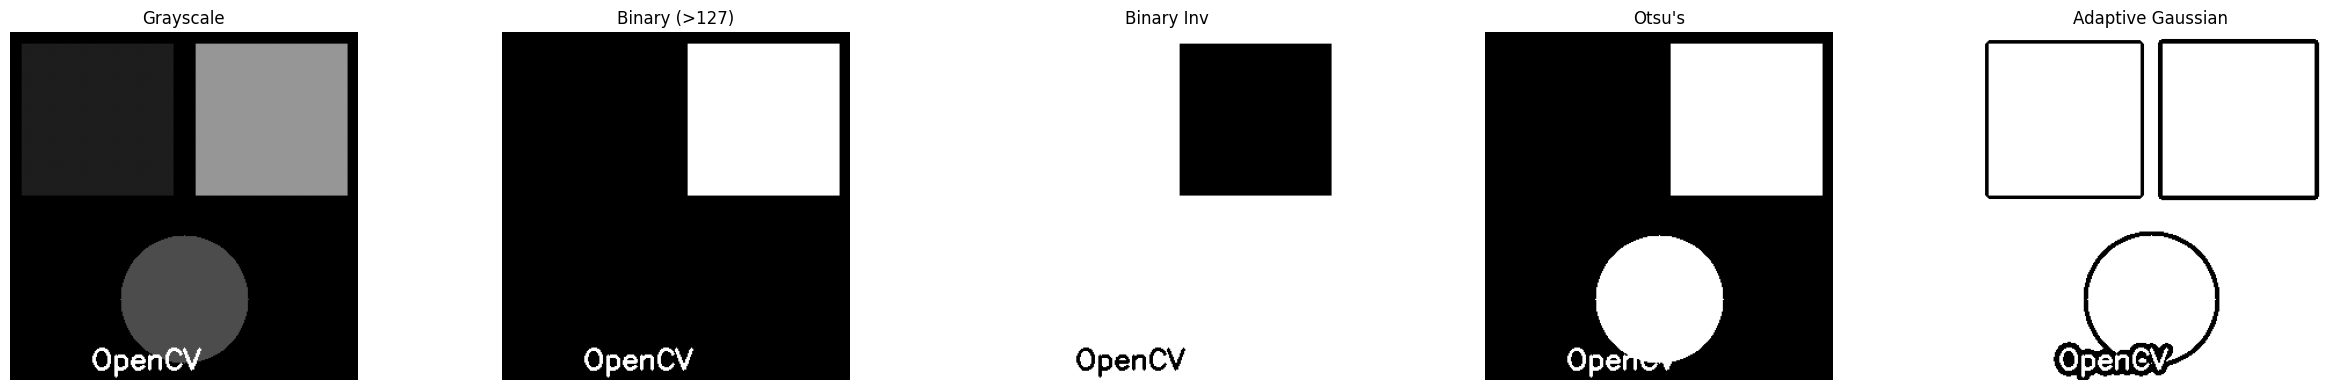

In [7]:
g = gray.copy()

ret1, thresh_binary = cv2.threshold(g, 127, 255, cv2.THRESH_BINARY)

ret2, thresh_inv    = cv2.threshold(g, 127, 255, cv2.THRESH_BINARY_INV)

ret3, thresh_otsu   = cv2.threshold(g, 0, 255,
                                    cv2.THRESH_BINARY + cv2.THRESH_OTSU)
thresh_adapt = cv2.adaptiveThreshold(g, 255,
                                      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY, 11, 2)

print(f'Otsu automatically chose threshold = {ret3}')

show_multi(
    ['Grayscale', 'Binary (>127)', 'Binary Inv', "Otsu's", 'Adaptive Gaussian'],
    [g, thresh_binary, thresh_inv, thresh_otsu, thresh_adapt],
    cols=5
)

---
## 6. Smoothing / Blurring Filters  –  `blur`, `GaussianBlur`, `medianBlur`, `bilateralFilter`.

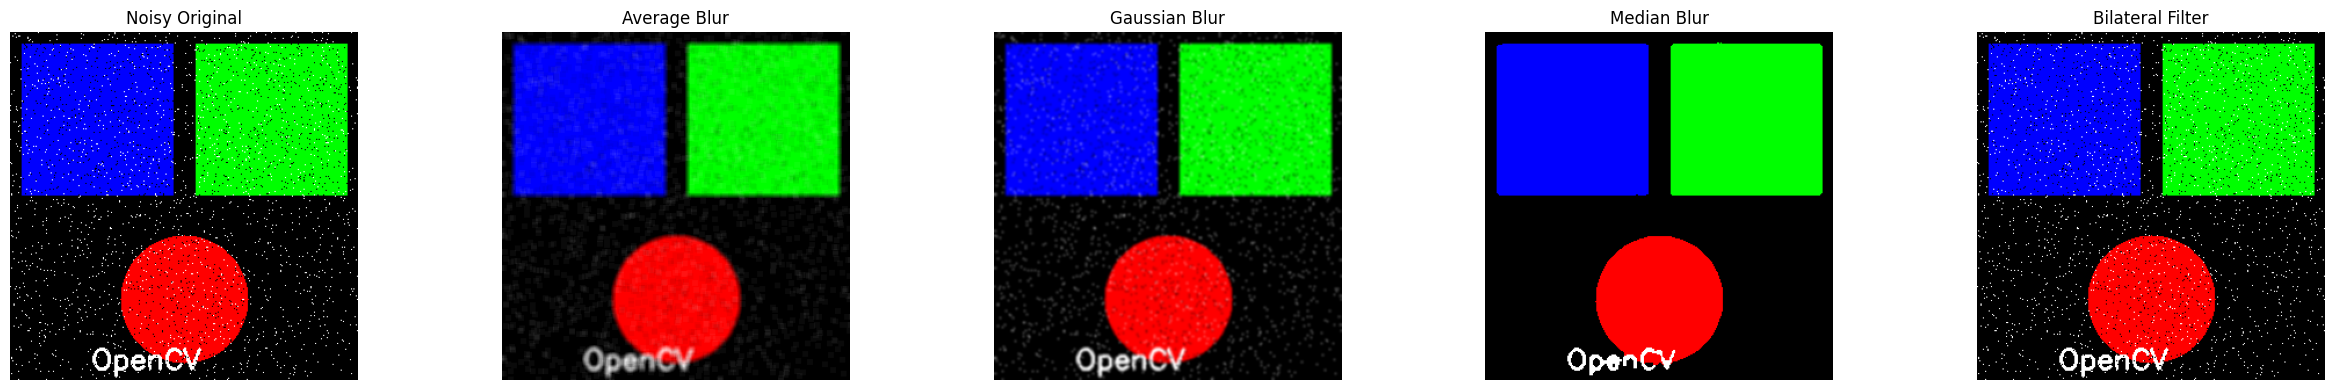

In [8]:
noisy = test_img.copy()
noise_mask = np.random.randint(0, 100, test_img.shape[:2])
noisy[noise_mask < 3]  = 0    # pepper
noisy[noise_mask > 97] = 255  # salt

avg_blur = cv2.blur(noisy, (5, 5))

gauss_blur = cv2.GaussianBlur(noisy, (5, 5), sigmaX=0)

median_blur = cv2.medianBlur(noisy, 5)

bilateral = cv2.bilateralFilter(noisy, d=9, sigmaColor=75, sigmaSpace=75)

titles = ['Noisy Original', 'Average Blur', 'Gaussian Blur',
          'Median Blur', 'Bilateral Filter']
imgs   = [cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
          for x in [noisy, avg_blur, gauss_blur, median_blur, bilateral]]

show_multi(titles, imgs, cmaps=[None]*5, cols=5)

---
## 7. Edge Detection  –  `cv2.Canny` and Sobel Gradients

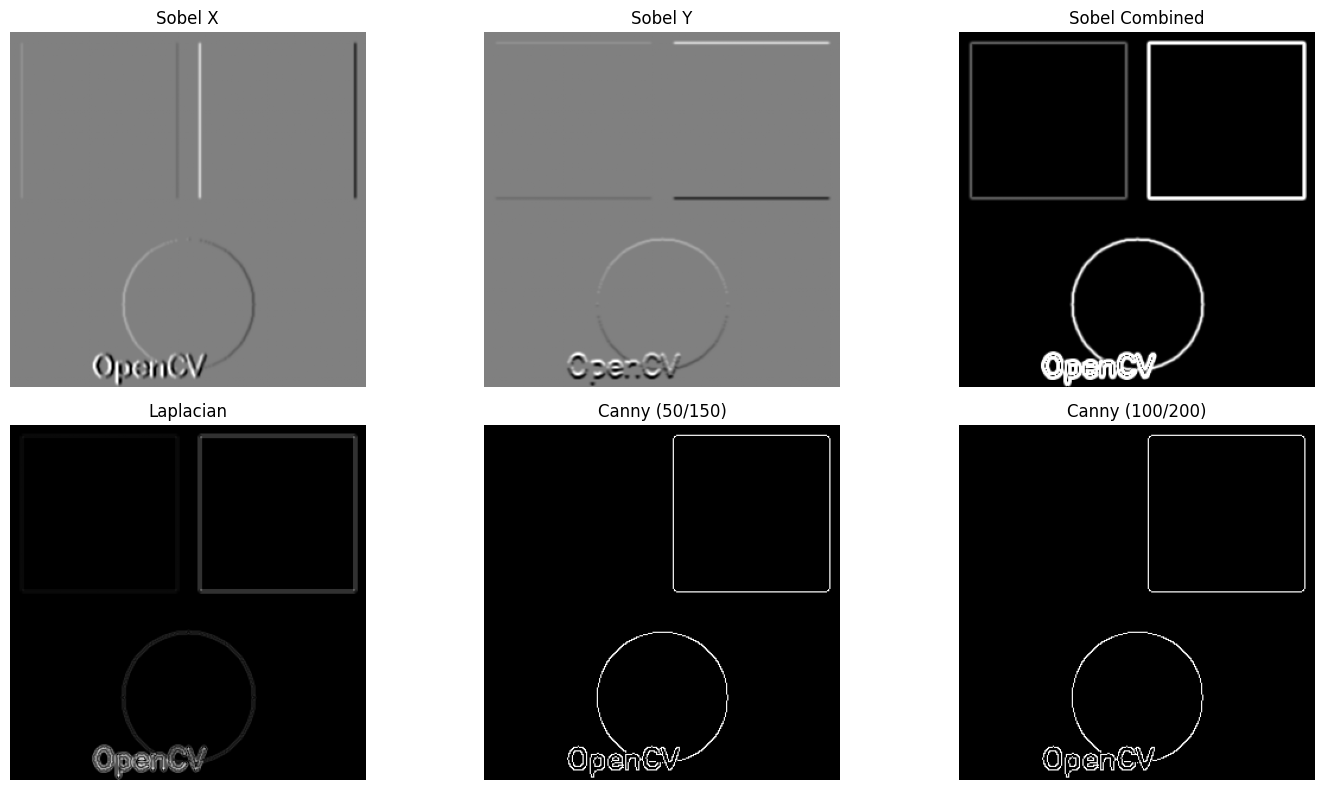

In [9]:
# Work on grayscale
blurred_gray = cv2.GaussianBlur(gray, (3, 3), 0)  # blur first reduces false edges

sobel_x = cv2.Sobel(blurred_gray, cv2.CV_64F, dx=1, dy=0, ksize=3)
sobel_y = cv2.Sobel(blurred_gray, cv2.CV_64F, dx=0, dy=1, ksize=3)
sobel_combined = cv2.magnitude(sobel_x, sobel_y)
sobel_combined = np.uint8(np.clip(sobel_combined, 0, 255))

# --- Laplacian ---
laplacian = cv2.Laplacian(blurred_gray, cv2.CV_64F)
laplacian = np.uint8(np.abs(laplacian))
canny_edges = cv2.Canny(blurred_gray, threshold1=50, threshold2=150)

# Try a different threshold to see the effect
canny_tight  = cv2.Canny(blurred_gray, 100, 200)

show_multi(
    ['Sobel X', 'Sobel Y', 'Sobel Combined',
     'Laplacian', 'Canny (50/150)', 'Canny (100/200)'],
    [sobel_x, sobel_y, sobel_combined,
     laplacian, canny_edges, canny_tight],
    cols=3
)

---
## 8. Morphological Operations  –  `erode`, `dilate`, `morphologyEx`

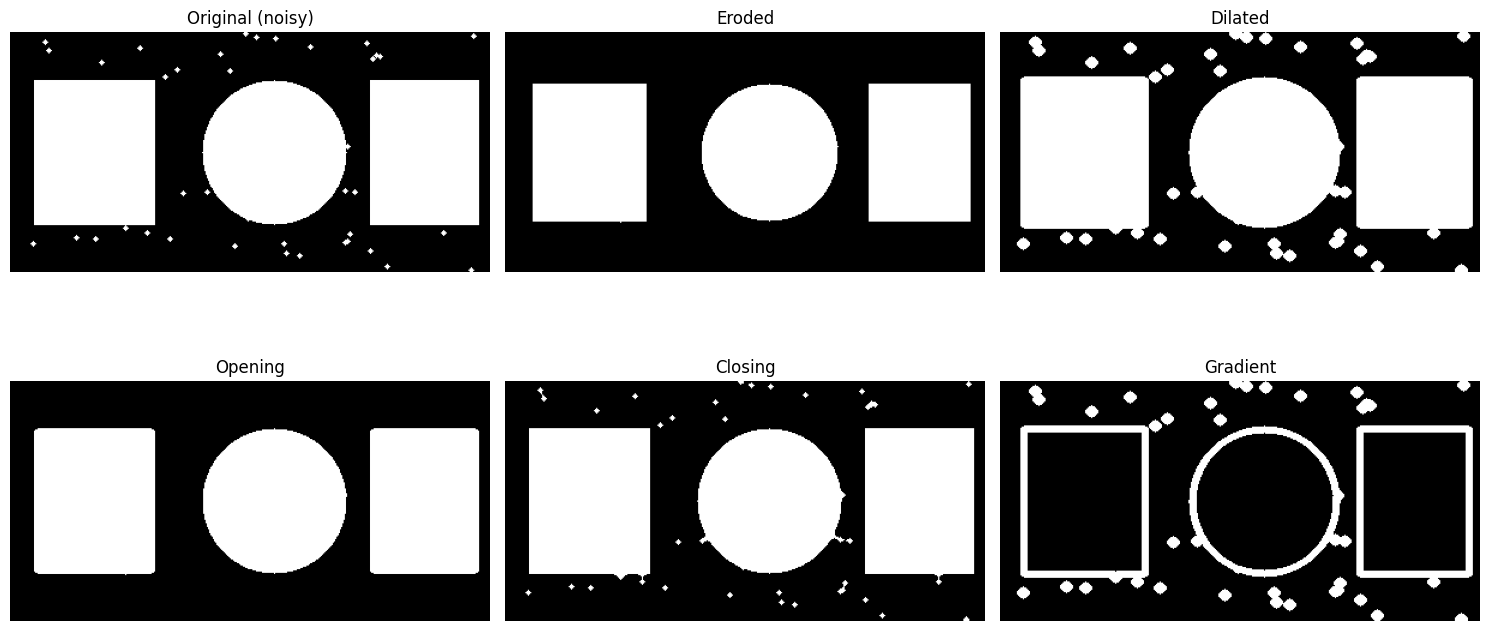

In [10]:
morph_img = np.zeros((200, 400), dtype=np.uint8)
cv2.rectangle(morph_img, (20, 40), (120, 160), 255, -1)
cv2.circle(morph_img,    (220, 100), 60,        255, -1)
cv2.rectangle(morph_img, (300, 40), (390, 160), 255, -1)

for _ in range(80):
    rx, ry = np.random.randint(0, 400), np.random.randint(0, 200)
    cv2.circle(morph_img, (rx, ry), 2, 255, -1)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

eroded = cv2.erode(morph_img, kernel, iterations=1)

# Dilation: grows white regions (fills small holes)
dilated = cv2.dilate(morph_img, kernel, iterations=1)

# Opening = erosion then dilation  -> removes small white dots (noise)
opened = cv2.morphologyEx(morph_img, cv2.MORPH_OPEN, kernel)

# Closing = dilation then erosion  -> fills small holes inside objects
closed = cv2.morphologyEx(morph_img, cv2.MORPH_CLOSE, kernel)

# Gradient = dilation - erosion  -> gives the outline of objects
gradient = cv2.morphologyEx(morph_img, cv2.MORPH_GRADIENT, kernel)

show_multi(
    ['Original (noisy)', 'Eroded', 'Dilated', 'Opening', 'Closing', 'Gradient'],
    [morph_img, eroded, dilated, opened, closed, gradient],
    cols=3
)

---
## 9. Contour Detection  –  `cv2.findContours` and `cv2.drawContours`

Number of contours found: 4
  Contour 0: area=6400, perimeter=386
  Contour 1: area=10040, perimeter=409
  Contour 2: area=10000, perimeter=400
  Contour 3: area=9322, perimeter=363


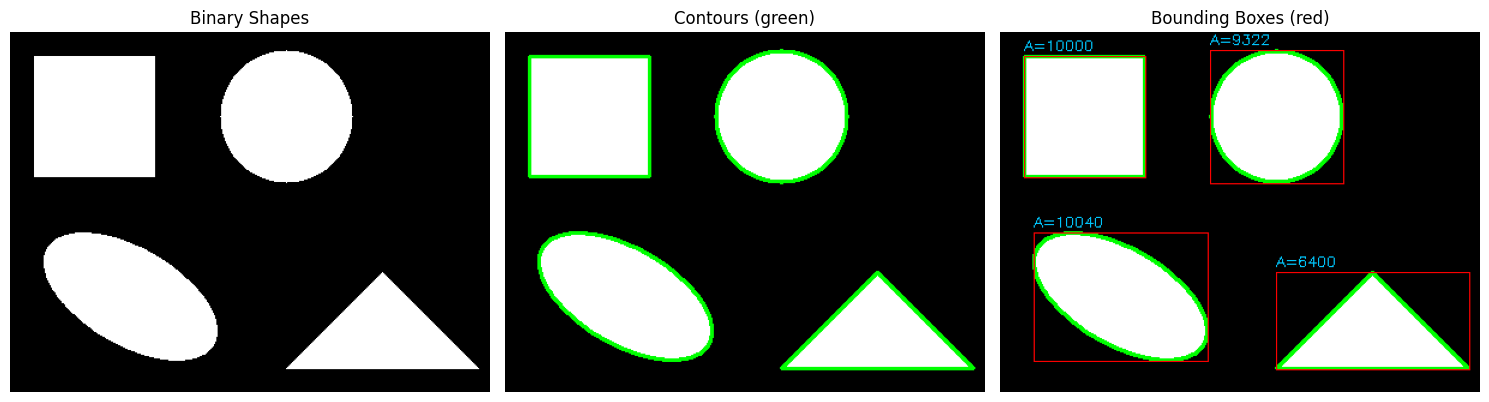

In [11]:
# Make a clean binary image with a few distinct shapes
shape_img = np.zeros((300, 400), dtype=np.uint8)
cv2.rectangle(shape_img, (20,  20), (120, 120), 255, -1)   # square
cv2.circle(shape_img,    (230, 70), 55,         255, -1)   # circle

triangle_pts = np.array([[310,200],[390,280],[230,280]], dtype=np.int32)
cv2.fillPoly(shape_img, [triangle_pts], 255)               # triangle

cv2.ellipse(shape_img, (100, 220), (80, 40), 30, 0, 360, 255, -1) # tilted ellipse

contours, hierarchy = cv2.findContours(shape_img,
                                        cv2.RETR_EXTERNAL,
                                        cv2.CHAIN_APPROX_SIMPLE)

print(f'Number of contours found: {len(contours)}')

# Draw contours on a colour copy
contour_drawn = cv2.cvtColor(shape_img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(contour_drawn, contours, -1, (0, 255, 0), 2)  # -1 = draw all

# For each contour, print some properties and draw a bounding box
annotated = contour_drawn.copy()
for i, cnt in enumerate(contours):
    area      = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, closed=True)
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(annotated, (x, y), (x+w, y+h), (0, 0, 255), 1)
    cv2.putText(annotated, f'A={int(area)}', (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 200, 0), 1)
    print(f'  Contour {i}: area={area:.0f}, perimeter={perimeter:.0f}')

show_multi(
    ['Binary Shapes', 'Contours (green)', 'Bounding Boxes (red)'],
    [shape_img,
     cv2.cvtColor(contour_drawn, cv2.COLOR_BGR2RGB),
     cv2.cvtColor(annotated,     cv2.COLOR_BGR2RGB)],
    cmaps=['gray', None, None],
    cols=3
)

---
## 10. Histogram and Histogram Equalisation  –  `cv2.calcHist`, `equalizeHist`, `CLAHE`

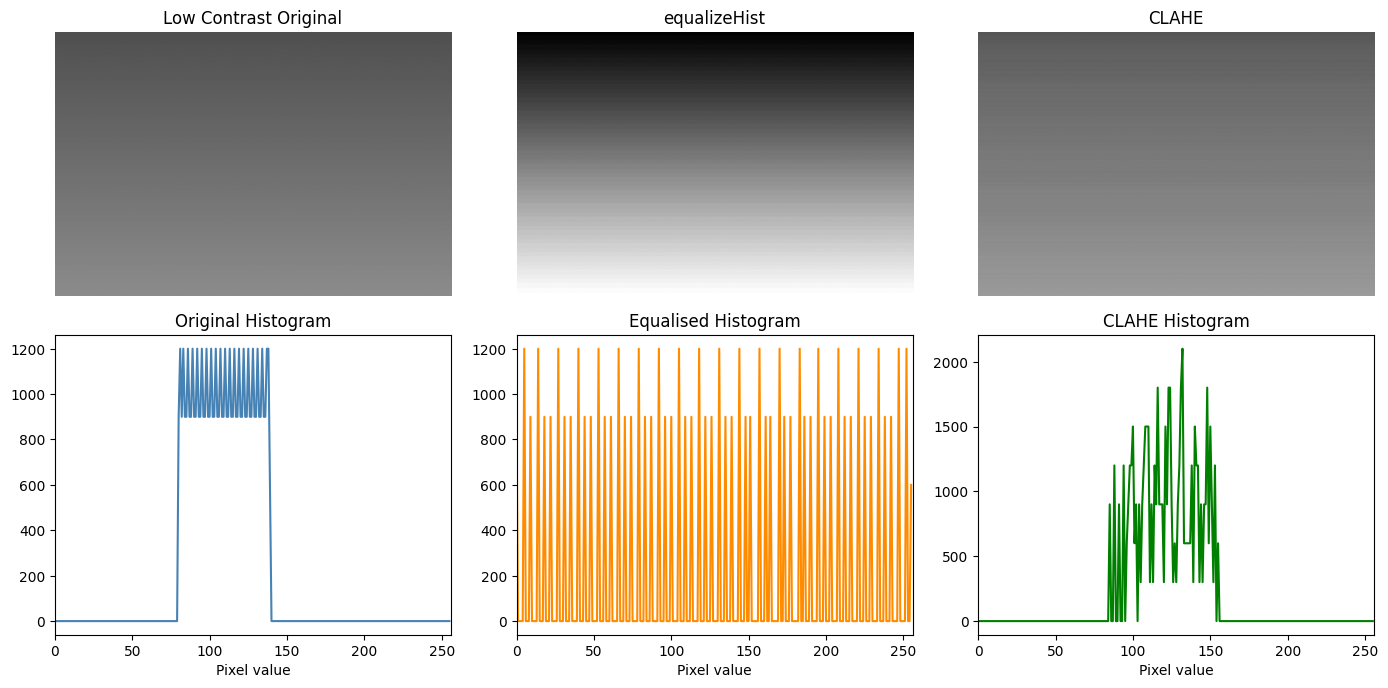

In [12]:
# Make a deliberately low-contrast grayscale image
low_contrast = np.zeros((200, 300), dtype=np.uint8)
for i in range(200):
    low_contrast[i, :] = int(80 + (i / 200.0) * 60)   # values only 80-140
low_contrast = cv2.GaussianBlur(low_contrast, (15, 15), 0)

# --- Standard equalisation ---
equalized = cv2.equalizeHist(low_contrast)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_result = clahe.apply(low_contrast)

# Calculate histograms for all three
def calc_hist(img):
    return cv2.calcHist([img], channels=[0], mask=None,
                        histSize=[256], ranges=[0, 256])

h_orig  = calc_hist(low_contrast)
h_eq    = calc_hist(equalized)
h_clahe = calc_hist(clahe_result)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, img, title in zip(axes[0],
                           [low_contrast, equalized, clahe_result],
                           ['Low Contrast Original', 'equalizeHist', 'CLAHE']):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title); ax.axis('off')

for ax, hist, title, colour in zip(axes[1],
                                    [h_orig, h_eq, h_clahe],
                                    ['Original Histogram', 'Equalised Histogram',
                                     'CLAHE Histogram'],
                                    ['steelblue', 'darkorange', 'green']):
    ax.plot(hist, color=colour); ax.set_title(title)
    ax.set_xlim([0, 256]); ax.set_xlabel('Pixel value')

plt.tight_layout()
plt.show()

---
## 11. Geometric Transformations  –  `warpAffine`, `warpPerspective`, `getRotationMatrix2D`

Geometric transforms move, rotate, flip, or skew an image. These come up a lot in data augmentation for training neural networks.

In [ ]:
src = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB).copy()
h, w = src.shape[:2]

# --- Flip ---
flip_h = cv2.flip(src, 1)   # 1 = horizontal
flip_v = cv2.flip(src, 0)   # 0 = vertical

# --- Rotation ---
# getRotationMatrix2D(centre, angle_degrees, scale)
centre = (w // 2, h // 2)
M_rot  = cv2.getRotationMatrix2D(centre, angle=45, scale=0.8)
rotated = cv2.warpAffine(src, M_rot, (w, h))

# --- Translation (shifting) ---
tx, ty = 40, 30  # shift 40 px right, 30 px down
M_trans = np.float32([[1, 0, tx],
                       [0, 1, ty]])
translated = cv2.warpAffine(src, M_trans, (w, h))

# --- Affine warp (shear) ---
pts1 = np.float32([[50, 50], [200, 50], [50, 200]])
pts2 = np.float32([[10, 80], [200, 50], [100, 250]])
M_aff = cv2.getAffineTransform(pts1, pts2)
affine = cv2.warpAffine(src, M_aff, (w, h))

# --- Perspective transform ---
pts_src  = np.float32([[0, 0],   [w-1, 0],   [0, h-1],   [w-1, h-1]])
pts_dst  = np.float32([[30, 30], [w-60, 10], [10, h-50], [w-30, h-30]])
M_persp  = cv2.getPerspectiveTransform(pts_src, pts_dst)
perspect = cv2.warpPerspective(src, M_persp, (w, h))

show_multi(
    ['Original', 'Flip H', 'Flip V', 'Rotate 45°', 'Translate', 'Affine', 'Perspective'],
    [src, flip_h, flip_v, rotated, translated, affine, perspect],
    cmaps=[None]*7, cols=4
)

---
## 12. Colour Masking and Segmentation  –  `cv2.inRange`

By defining a range of HSV values we can isolate a specific colour in an image. This technique is used in object tracking and simple segmentation tasks.

In [ ]:
# Use the HSV version of our test image (which has a red, green, and blue region)
hsv_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2HSV)

# --- Isolate the GREEN region ---
# In HSV: green hue is roughly 35-85
lower_green = np.array([35,  50,  50])
upper_green = np.array([85, 255, 255])
mask_green  = cv2.inRange(hsv_img, lower_green, upper_green)

# --- Isolate the BLUE region ---
# Blue hue is roughly 100-130
lower_blue  = np.array([100, 50,  50])
upper_blue  = np.array([130, 255, 255])
mask_blue   = cv2.inRange(hsv_img, lower_blue, upper_blue)

# --- Isolate RED (red wraps around 0/180 in HSV) ---
lower_red1 = np.array([0,   100, 100])
upper_red1 = np.array([10,  255, 255])
lower_red2 = np.array([170, 100, 100])
upper_red2 = np.array([180, 255, 255])
mask_red   = cv2.inRange(hsv_img, lower_red1, upper_red1) | \
             cv2.inRange(hsv_img, lower_red2, upper_red2)

# Apply masks back to original (bitwise_and keeps only masked pixels)
result_green = cv2.bitwise_and(test_img, test_img, mask=mask_green)
result_blue  = cv2.bitwise_and(test_img, test_img, mask=mask_blue)
result_red   = cv2.bitwise_and(test_img, test_img, mask=mask_red)

titles = ['Original', 'Green mask', 'Isolated Green',
          'Blue mask',  'Isolated Blue',
          'Red mask',   'Isolated Red']
imgs   = [cv2.cvtColor(x, cv2.COLOR_BGR2RGB) if len(x.shape)==3 else x
          for x in [test_img, mask_green, result_green,
                    mask_blue, result_blue,
                    mask_red,  result_red]]
cmaps  = [None, 'gray', None, 'gray', None, 'gray', None]

show_multi(titles, imgs, cmaps=cmaps, cols=4)

---
## 13. Template Matching  –  `cv2.matchTemplate`

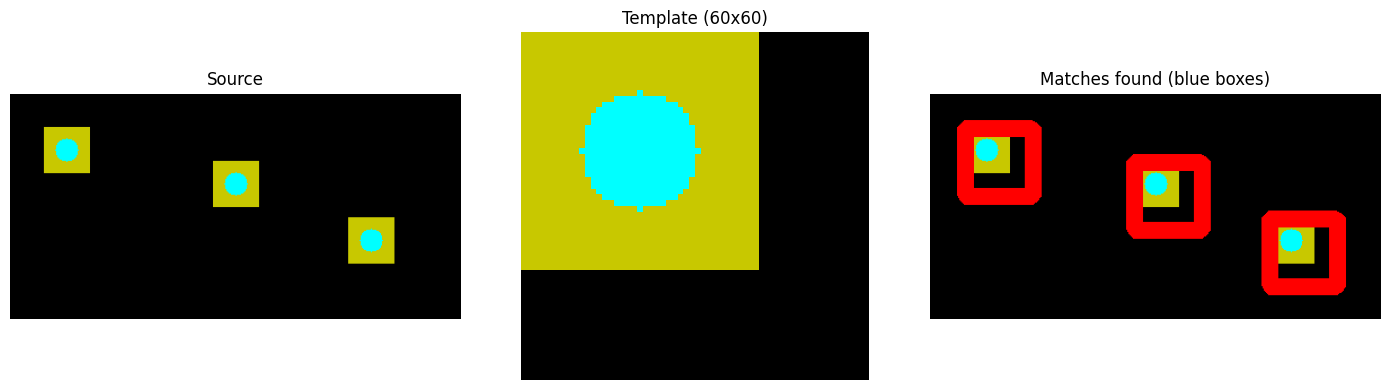

Matches found at threshold >= 0.7: 297 location(s)


In [13]:
# Source image: a simple pattern grid
source = np.zeros((200, 400, 3), dtype=np.uint8)
positions = [(50, 50), (200, 80), (320, 130)]
for (cx, cy) in positions:
    cv2.rectangle(source, (cx-20, cy-20), (cx+20, cy+20), (0, 200, 200), -1)
    cv2.circle(source, (cx, cy), 10, (255, 255, 0), -1)

# Template: crop the first occurrence of our pattern
template = source[30:90, 30:90].copy()  # 60x60 region

# Run template matching with normalised cross-correlation
# TM_CCOEFF_NORMED gives values from -1 to 1; closer to 1 = better match
result = cv2.matchTemplate(source, template, cv2.TM_CCOEFF_NORMED)

threshold = 0.7
loc = np.where(result >= threshold)

th, tw = template.shape[:2]
detected = cv2.cvtColor(source, cv2.COLOR_BGR2RGB).copy()
for pt in zip(*loc[::-1]):   # loc gives (rows, cols), flip to (x, y)
    cv2.rectangle(detected, pt, (pt[0]+tw, pt[1]+th), (255, 0, 0), 2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(cv2.cvtColor(source,   cv2.COLOR_BGR2RGB)); axes[0].set_title('Source'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(template, cv2.COLOR_BGR2RGB)); axes[1].set_title('Template (60x60)'); axes[1].axis('off')
axes[2].imshow(detected);                                   axes[2].set_title('Matches found (blue boxes)'); axes[2].axis('off')
plt.tight_layout(); plt.show()

print(f'Matches found at threshold >= {threshold}: {len(list(zip(*loc[::-1])))} location(s)')

---
## 14. Feature Detection  –  `cv2.ORB` (SIFT alternative that is free to use)

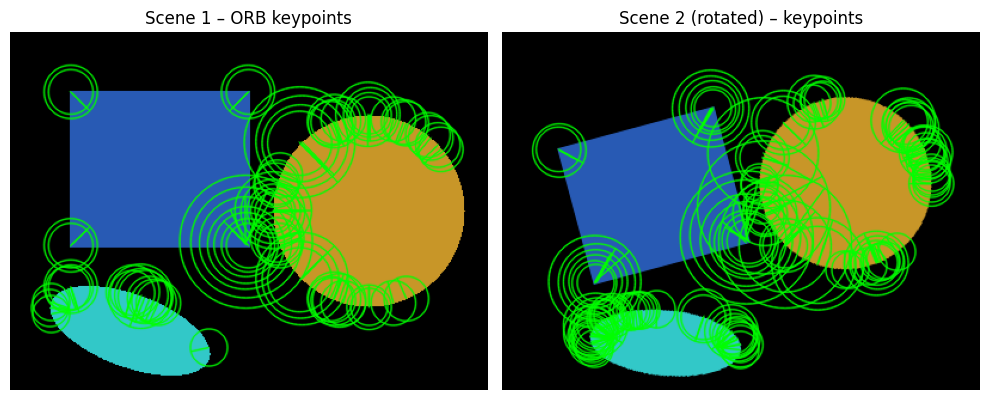

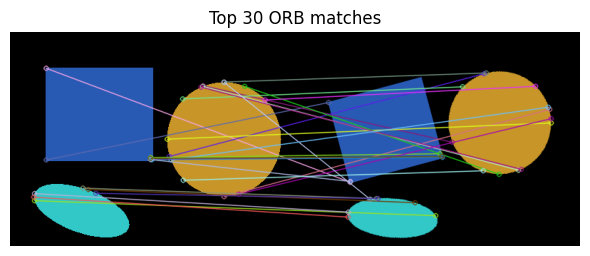

Keypoints in scene1: 70
Keypoints in scene2: 105
Total matches found: 27


In [14]:
# Create two slightly different views of the same scene
scene = np.zeros((300, 400, 3), dtype=np.uint8)
cv2.rectangle(scene, (50,  50),  (200, 180), (180, 90,  40),  -1)
cv2.circle(scene,    (300, 150), 80,          (40,  150, 200), -1)
cv2.ellipse(scene,   (100, 250), (70, 30), 20, 0, 360, (200, 200, 50), -1)

# Second view: slightly rotated and scaled
M = cv2.getRotationMatrix2D((200, 150), 15, 0.9)
scene2 = cv2.warpAffine(scene, M, (400, 300))

gray1 = cv2.cvtColor(scene,  cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(scene2, cv2.COLOR_BGR2GRAY)

# Initialise ORB detector
# nfeatures = max number of keypoints to detect
orb = cv2.ORB_create(nfeatures=200)

# Detect keypoints and compute descriptors
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

# Match descriptors using Brute Force matcher
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)  # sort by quality

# Draw keypoints on each image
img_kp1 = cv2.drawKeypoints(scene,  kp1, None, color=(0, 255, 0),
                              flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img_kp2 = cv2.drawKeypoints(scene2, kp2, None, color=(0, 255, 0),
                              flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Draw top 30 matches between the two images
matched_img = cv2.drawMatches(scene, kp1, scene2, kp2,
                               matches[:30], None,
                               flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

show_multi(
    ['Scene 1 – ORB keypoints', 'Scene 2 (rotated) – keypoints'],
    [cv2.cvtColor(img_kp1, cv2.COLOR_BGR2RGB),
     cv2.cvtColor(img_kp2, cv2.COLOR_BGR2RGB)],
    cmaps=[None, None], cols=2
)
show('Top 30 ORB matches', cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB), cmap=None)

print(f'Keypoints in scene1: {len(kp1)}')
print(f'Keypoints in scene2: {len(kp2)}')
print(f'Total matches found: {len(matches)}')

---
## Summary

| # | Function(s) | What it does |
|---|-------------|-------------|
| 1 | `np.zeros`, `cv2.rectangle/circle/putText` | Create images and draw basic shapes |
| 2 | `cv2.cvtColor` | Convert between colour spaces (BGR↔RGB, Grayscale, HSV, LAB) |
| 3 | `cv2.resize` | Scale images up/down with different interpolation modes |
| 4 | Drawing functions | `line`, `rectangle`, `circle`, `ellipse`, `polylines`, `putText` |
| 5 | `cv2.threshold`, `adaptiveThreshold` | Binary segmentation of grayscale images |
| 6 | `blur`, `GaussianBlur`, `medianBlur`, `bilateralFilter` | Noise reduction |
| 7 | `cv2.Canny`, `Sobel`, `Laplacian` | Edge and gradient detection |
| 8 | `erode`, `dilate`, `morphologyEx` | Shape-based noise removal and feature extraction |
| 9 | `findContours`, `drawContours` | Detect and analyse object boundaries |
|10 | `calcHist`, `equalizeHist`, `CLAHE` | Histogram analysis and contrast enhancement |
|11 | `warpAffine`, `warpPerspective`, `flip` | Geometric transformations |
|12 | `cv2.inRange`, `bitwise_and` | Colour-based masking and segmentation |
|13 | `matchTemplate` | Sliding-window template/object search |
|14 | `ORB`, `BFMatcher`, `drawMatches` | Keypoint detection and matching |
|15 | `add`, `addWeighted`, `absdiff`, bitwise ops | Image arithmetic and logical operations |